In [1]:
#!pip install ipywidgets

In [1]:
### Loading Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from datetime import timedelta
from sklearn.metrics import mean_squared_error


!pip install neuralprophet[live] --quiet
from neuralprophet import NeuralProphet
from neuralprophet import set_random_seed
set_random_seed(0)

fpath = "D:\\paper\\C\\data\\5\\6data_0.6.csv"

df = pd.read_csv(fpath)
demand_df = df[['date','Requests']].rename(columns={"date": "ds", "Requests": "y"})
demand_df['ds'] = pd.to_datetime(demand_df['ds'])

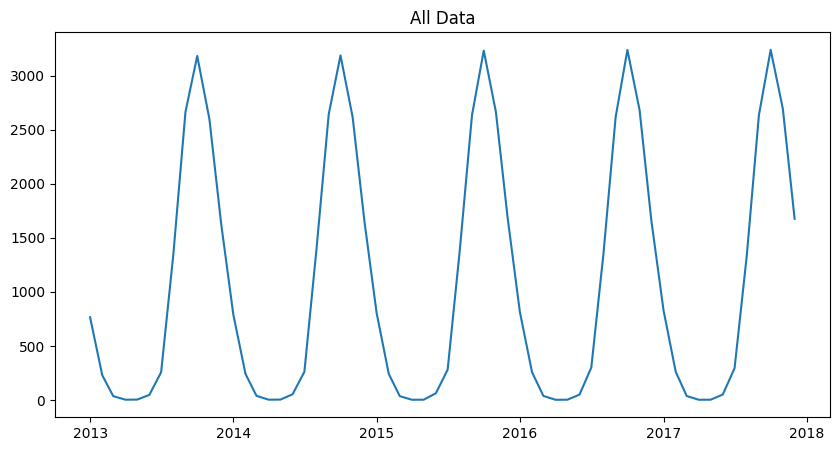

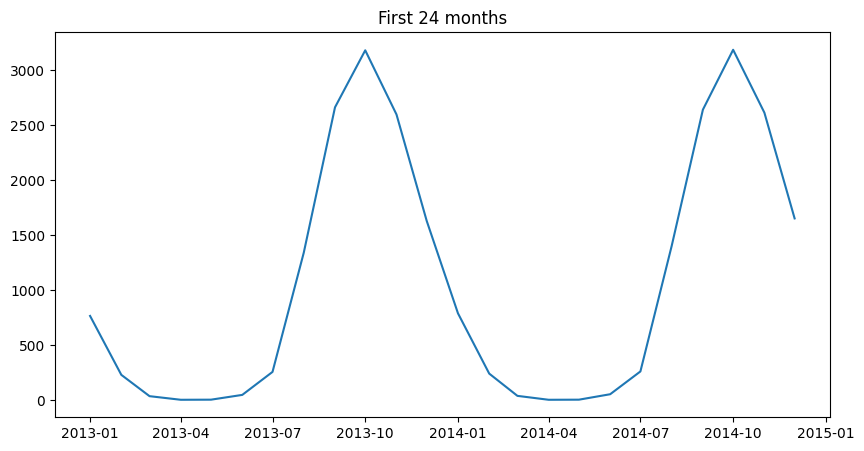

In [2]:
###  Matplotlib to visualize the data

plt.figure(figsize=(10, 5))
plt.title("All Data")
plt.plot(demand_df['ds'].dt.to_pydatetime(), demand_df['y'])
plt.show()

plt.figure(figsize=(10, 5))
plt.title("First 24 months")
plt.plot(demand_df['ds'].dt.to_pydatetime()[:24], demand_df['y'][:24])
plt.show()

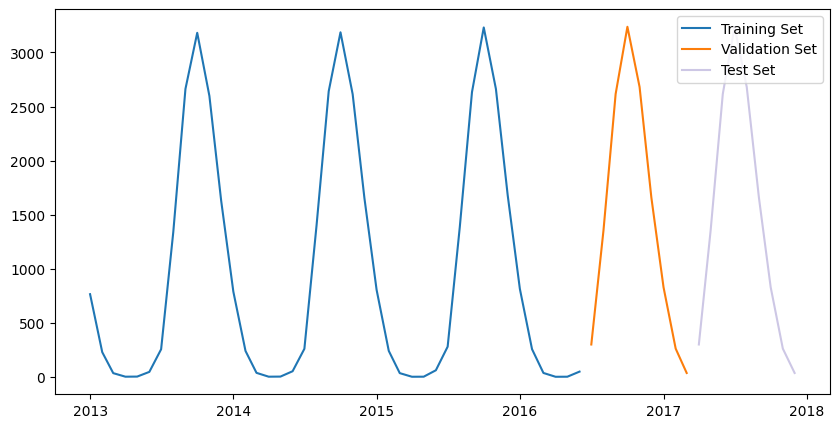

In [3]:
## creating a validation and testing set
#Note that the validation and testing set should always contain the most recent data points.
#This ensures that we do not train on data from the future and make predictions on the past.

train_size = 0.7

m = NeuralProphet()
df_train, df_valid = demand_df[:int(len(demand_df)*0.7)], demand_df[int(len(demand_df)*0.7):]
df_valid, df_test = df_valid[:len(df_valid)//2], df_valid[len(df_valid)//2:]

def train_valid_plot():
    """Visualizing the training + validation sets"""
    fig = plt.figure(figsize=(10,5))
    ax = fig.add_subplot(111)
    ax.plot(df_train['ds'].dt.to_pydatetime(), df_train["y"], color='#1f76b4', label='Training Set')
    ax.plot(df_valid['ds'].dt.to_pydatetime(), df_valid["y"], color='#fc7d0b', label='Validation Set')
    ax.plot(df_test['ds'].dt.to_pydatetime(), df_valid["y"], color='#CDC7E5', label='Test Set')
    ax.legend()
    plt.show()
    
train_valid_plot()

In [4]:
###  Defining a Model>>  NeuralProphet 
#n the following cell, we are simply defining a model and fitting this model to the data.
#We use ‘MS’ to set the frequency of predictions as monthly, 
#The only other alteration we make is to specify Pakistan holidays. ??????

In [5]:
m = NeuralProphet()

#m.add_country_holidays(country_name='Pakistan')
metrics = m.fit(df=df_train, validation_df=df_valid, freq="MS", progress="plot-all")
metrics[-1:]


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 991
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (3) is too small than the required number for the learning rate finder (203). The results might not be optimal.


Finding best initial lr:   0%|          | 0/203 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,MAE,RMSE,Loss,RegLoss
990,50.840908,57.202332,0.000165,0.0,990,9.242647,11.540967,0.000005,0.0


In [6]:

m = NeuralProphet(epochs=2000)
#m.add_country_holidays(country_name='Australia')
metrics2 = m.fit(df=df_train, validation_df=df_valid, freq="MS")
### ?????????? freq=MS  is right ??????   ######
#By specifying the number of epochs, we significantly reduce the validation RMSE. Even changing one parameter can improve our model significantly (as shown above). This suggests that using parameter tuning and translating domain knowledge to the model can improve its performance.

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (3) is too small than the required number for the learning rate finder (203). The results might not be optimal.


Finding best initial lr:   0%|          | 0/203 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [7]:
###  ????????? RMSE increased!!!!!!!!!

In [8]:
### Model Evaluation

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.235% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.235% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 3it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


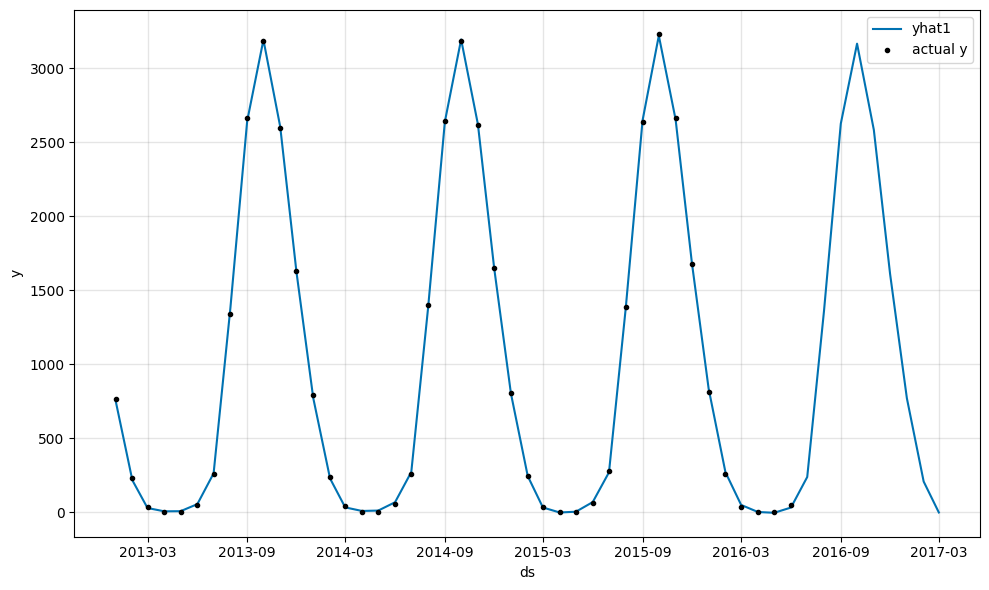

In [9]:
#making a forecast that is the same length as the validation set.
#visualize this using the .plot() function
future = m.make_future_dataframe(df=df_train, periods=len(df_valid), n_historic_predictions=True)
forecast = m.predict(df=future)
fig_forecast = m.plot(forecast)


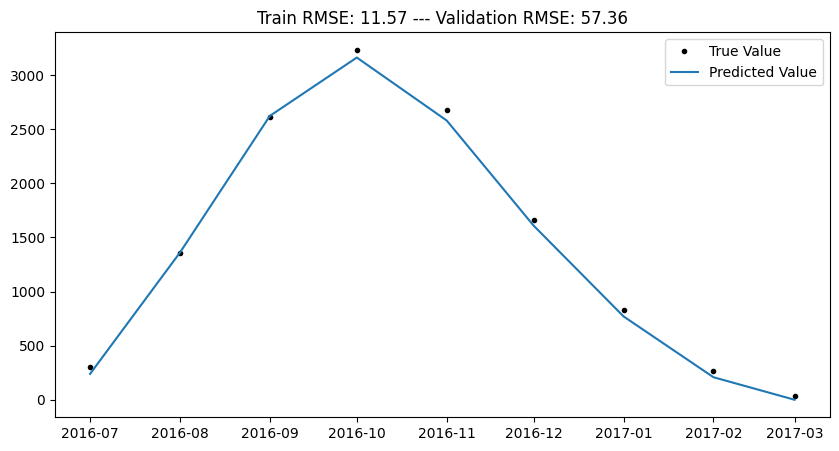

In [10]:
#To address the limitations of the built-in plot, I put together a customized plot using Matplotlib.
#The following cell plots the predictions with the true labels and shows the model metrics in the plot title.
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.set_title("Train RMSE: {:.2f} --- Validation RMSE: {:.2f}".format(metrics2[-1:].RMSE.values[0], metrics2[-1:].RMSE_val.values[0]))
ax.plot(df_valid['ds'].dt.to_pydatetime(), df_valid["y"],'.k', label='True Value')
ax.plot(forecast[-len(df_valid):]['ds'].dt.to_pydatetime(), forecast[-len(df_valid):]["yhat1"], label='Predicted Value')
ax.legend()
plt.show()

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


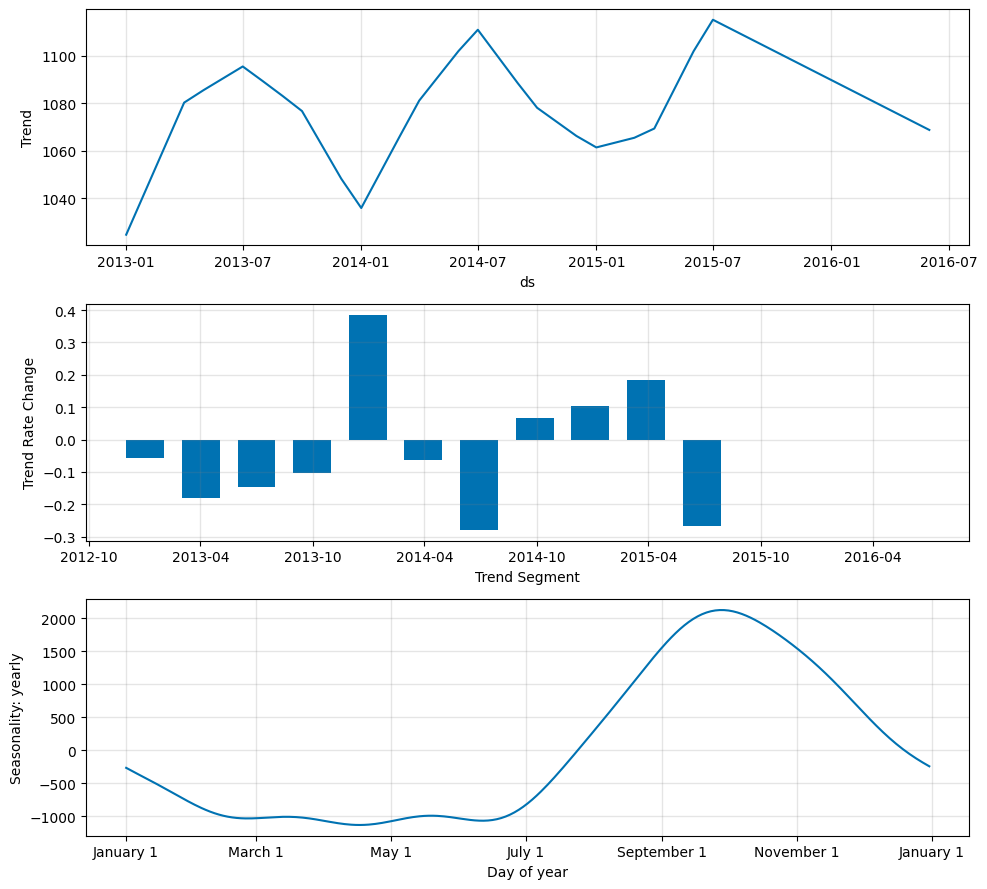

In [11]:
# fig_comp = m.plot_components(forecast) # Alternative: shows a slightly different figure
fig_param = m.plot_parameters()

In [12]:
### Adding AR-Net (AutoRegression)
#This allows NeuralProphet to use observations from previous time steps when making a prediction.
#In our case, this means that the model can use the previous day’s energy demands to make its predictions.

In [13]:

m = NeuralProphet(n_forecasts=1, n_lags=3, epochs=2000, changepoints_range=0.95)
#m.add_country_holidays(country_name='Australia')
metrics3 = m.fit(df=df_train, validation_df=df_valid, freq="MS")

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (3) is too small than the required number for the learning rate finder (203). The results might not be optimal.


Finding best initial lr:   0%|          | 0/203 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [14]:
###  ????????? RMSE increased!!!!!!!!!

In [15]:
valid_preds = [] #list to store predictions
lags = 3

for d in df_valid['ds'].values:
    # getting necessary df rows
    date_index = demand_df.index[demand_df['ds'] == d][0]
    future = demand_df.iloc[date_index-lags:date_index]
    
    # adding new row
    entry = pd.DataFrame({
        'ds': [d],
        'y' : [np.nan]
    })
    future = pd.concat([future, entry], ignore_index = True, axis = 0)
    
    # making prediction
    forecast = m.predict(df=future)
    valid_preds.append(forecast.loc[lags]['yhat1'])

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 3it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 3it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 3it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 3it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [16]:
#  plot our predictions

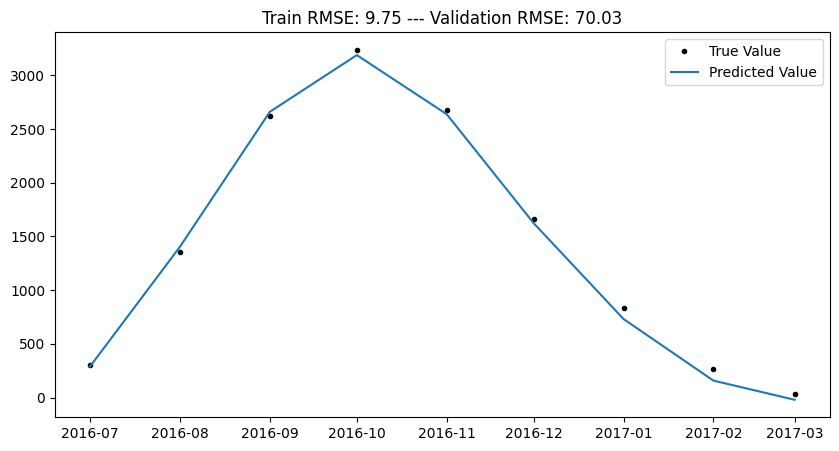

In [17]:

# Creating DF for predictions
df_valid_copy = df_valid.copy()
df_valid_copy['yhat1'] = valid_preds
df_valid_copy.head()

# Plotting Predictions
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.set_title("Train RMSE: {:.2f} --- Validation RMSE: {:.2f}".format(metrics3[-1:].RMSE.values[0], metrics3[-1:].RMSE_val.values[0]))
ax.plot(df_valid_copy['ds'].dt.to_pydatetime(), df_valid_copy["y"],'.k', label='True Value')
ax.plot(df_valid_copy['ds'].dt.to_pydatetime(), df_valid_copy["yhat1"], label='Predicted Value')
ax.legend()
plt.show()
#We can see from the plot that the model is starting to pick up on outlying points.

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


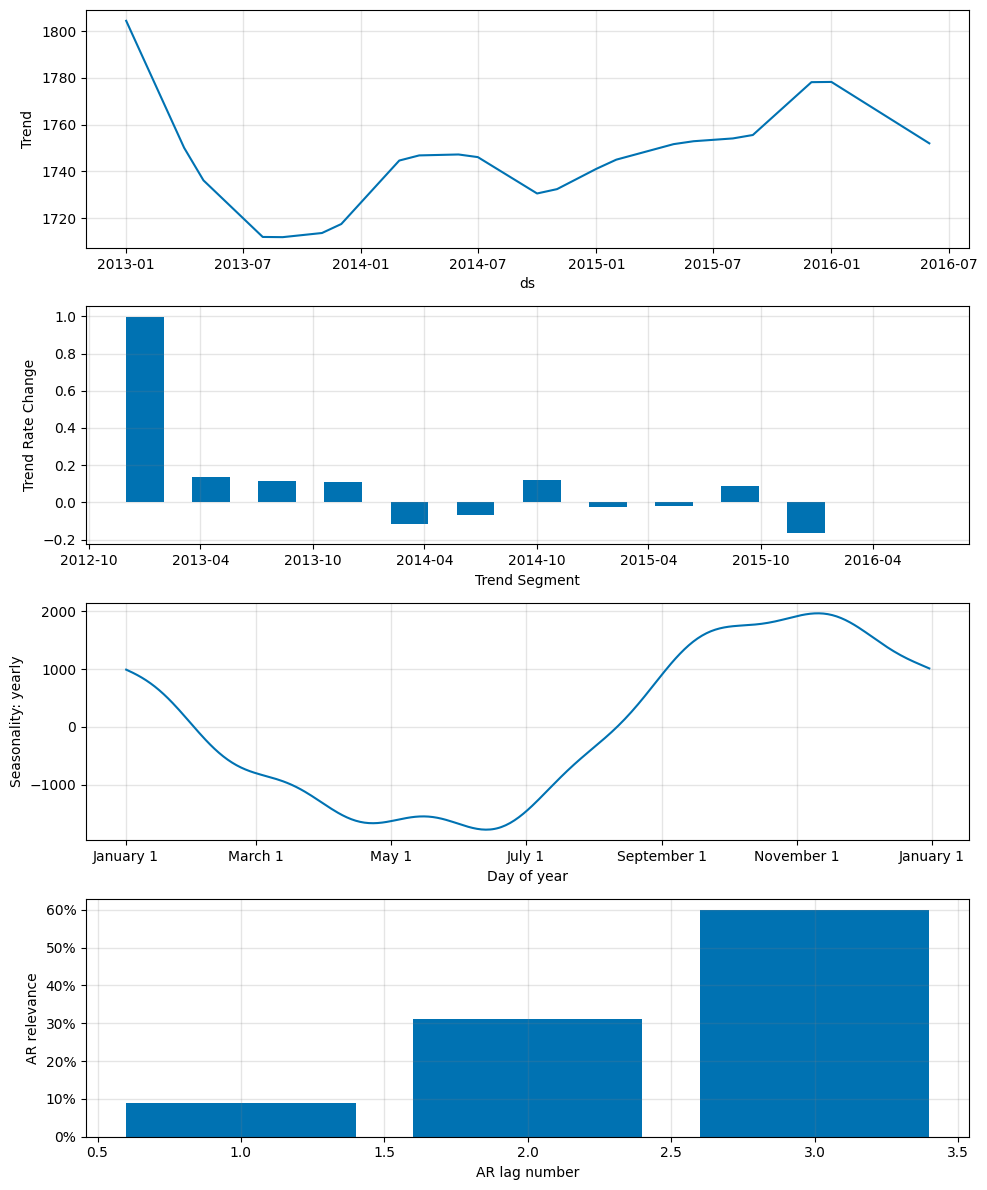

In [18]:

fig_param = m.plot_parameters()

#an additional plot =how much each lagged term affects the prediction

In [107]:
#Hyperparameter tuning
#Next, we are creating a Pandas dataframe to store the lowest RMSE value from each model training cycle.
#We can then sort by the validation RMSE value, to get a sense of which parameter combinations worked well.
#The training RMSE score and epoch where when the validation score was at its lowest are also stored.
#This is done to ensure that the model is not overfitting to the validation set.
# Best Model Parameters —> RMSE_val, RMSE_train, score_epoch_number, num_hidden_layers, changepoints_range

# Parameter Options=using bayesian optimization to more efficiently search the parameter space,
param_grid = {  
    'num_hidden_layers': [1,2],
    'changepoints_range': [0.95, 0.975, 0.995, 0.998, 0.999],
              }

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
results = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = NeuralProphet(**params, n_forecasts=1, newer_samples_weight=4, n_lags=3, learning_rate=0.02, epochs=75, batch_size=32)
    #m.add_country_holidays(country_name='Australia')
    metrics4 = m.fit(df=df_train, validation_df=df_valid, freq="MS")
    results.append(dict({"RMSE_val": metrics4['RMSE_val'].min(), "RMSE_train": metrics4['RMSE'][metrics4['RMSE_val'].idxmin()], "score_epoch_number": metrics4['RMSE_val'].idxmin()}, **params))

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [108]:
#re-entering high scoring model parameters

m = NeuralProphet(newer_samples_weight=5, n_forecasts=1, n_lags=3, learning_rate=0.02, epochs=75, batch_size=32, num_hidden_layers=1, changepoints_range=0.998)
#m.add_country_holidays(country_name='Australia')
metrics5 = m.fit(df=df_train, validation_df=df_valid, freq="MS", progress="plot-all")

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [109]:
valid_preds = [] #list to store predictions
lags = 3

for d in df_valid['ds'].values:
    # getting necessary df rows
    date_index = demand_df.index[demand_df['ds'] == d][0]
    future = demand_df.iloc[date_index-lags:date_index]
    
    # adding new row
    entry = pd.DataFrame({
        'ds': [d],
        'y' : [np.nan]
    })
    future = pd.concat([future, entry], ignore_index = True, axis = 0)
    
    # making prediction
    forecast = m.predict(df=future)
    valid_preds.append(forecast.loc[lags]['yhat1'])
    


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


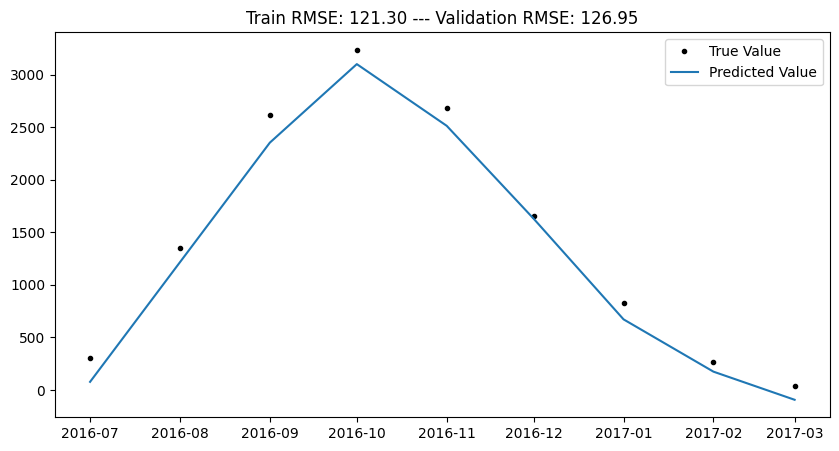

In [110]:
# Creating DF for predictions
#plot our predictions
df_valid_copy = df_valid.copy()
df_valid_copy['yhat1'] = valid_preds
df_valid_copy.head()

# Plotting Predictions
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.set_title("Train RMSE: {:.2f} --- Validation RMSE: {:.2f}".format(metrics5[-1:].RMSE.values[0], metrics5[-1:].RMSE_val.values[0]))
ax.plot(df_valid_copy['ds'].dt.to_pydatetime(), df_valid_copy["y"],'.k', label='True Value')
ax.plot(df_valid_copy['ds'].dt.to_pydatetime(), df_valid_copy["yhat1"], label='Predicted Value')
ax.legend()
plt.show()

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\AppData\Local\Programs\Python\Python37\lib\site-packages\neuralprophet\plot_model_parameters_matplotlib.py:422: RuntimeWarning: invalid value encountered in true_divide
  weights = weights / np.sum(weights)



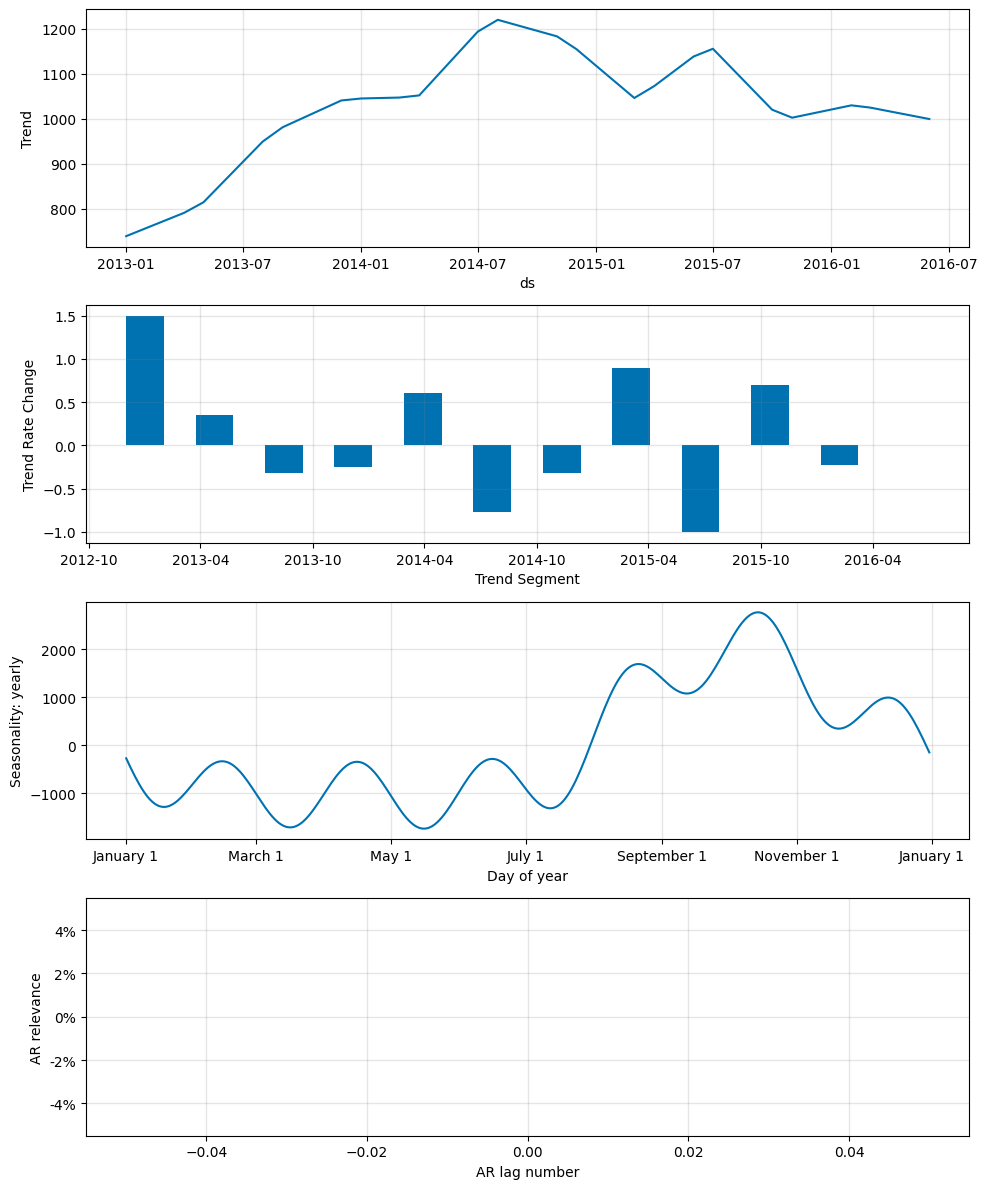

In [111]:
fig_param = m.plot_parameters()

In [112]:
###  Model Performance Comparison   ###
#n the next cell, I am going to compare the NeuralProphet model with other common forecasting strategies.

# 1 Predict Last Value
# 2 Exponential Smoothing
# 3 SARIMA
# 4 Neural Prophet

In [113]:
#We can manually calculate the RMSE value for each model using sklearn. We can simply pass the parameter squared=False to get RMSE from the mean_squared_error function.

#Firstly, we can calculate the RMSE if we just predicted the energy demand from the day before.
#@ Last Value Method
last_val_df = demand_df.copy()

last_val_df['y_prev'] = last_val_df['y'].shift(1)
last_val_df = last_val_df[last_val_df['ds'].isin(df_test['ds'].values)]
last_val_preds = last_val_df['y'].values

last_val_rmse = mean_squared_error(last_val_preds, last_val_df['y_prev'], squared=False)


In [114]:
#calculate a forecasting model using exponential smoothing.
#This model type uses the weighted averages of past observations, with weights decaying exponentially as observations get older.

#@ Exponential Smoothing Method
from statsmodels.tsa.api import SimpleExpSmoothing

exp_smooth_preds = []

for d in df_test['ds'].values:
    # Setting up Dataframe
    date_index = demand_df.index[demand_df['ds'] == d][0]
    future = demand_df.iloc[date_index-len(df_train):date_index]
    future = future.set_index('ds')
    future.index = pd.DatetimeIndex(future.index.values, freq='MS')
    
    # Make Predictions
    fit = SimpleExpSmoothing(future, initialization_method="heuristic").fit(
            smoothing_level=0.2, optimized=False
        )
    
    exp_smooth_preds.append(fit.forecast(1).values[0])
    
exp_smooth_rmse = mean_squared_error(df_test['y'], exp_smooth_preds, squared=False)

In [115]:
# fit a SARIMA model to the data
#This model acronym stands for “Seasonal Auto-Regressive Integrated Moving Average”, and calculates its forecast exactly how it is named.
#This model is a little more complex, and we will break the training into code blocks. Firstly, the optimal model parameters are found using autoarima.
#This is essentially a hyper-parameter tuning package for ARIMA models.

In [116]:
#!pip install pmdarima

In [117]:
#@ SARIMA Method
!pip install pmdarima --quiet
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

# Seasonal - Find best parameters with Auto-ARIMA
SARIMA_model = pm.auto_arima(df_train["y"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, 
                         m=7, #weekly frequency
                         start_P=0, 
                         seasonal=True, #set to seasonal
                         d=None, 
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)
                         
sarima_preds = []

for d in df_test['ds'].values:
    # Setting up dataframe
    date_index = demand_df.index[demand_df['ds'] == d][0]
    future = demand_df.iloc[date_index-len(df_train):date_index]
    future = future.set_index('ds')
    future.index = pd.DatetimeIndex(future.index.values, freq='MS')
    
    # Fit model + make predictions
    m_sarima = ARIMA(future['y'], order=(1,0,1), seasonal_order=(0, 1, 1, 7)).fit()
    sarima_preds.append(m_sarima.forecast(1).values[0])
    
sarima_rmse = mean_squared_error(df_test['y'], sarima_preds, squared=False)

In [118]:
#@  Finally, we can make predictions with the NeuralProphet Model.   ###

In [119]:
m = NeuralProphet(newer_samples_weight=5, n_forecasts=1, n_lags=3, learning_rate=0.02, epochs=50, batch_size=32, num_hidden_layers=1, changepoints_range=0.998)
#m.add_country_holidays(country_name='Australia')
metrics6 = m.fit(df=df_train, freq="MS")

neuralprophet_preds = [] #list to store predictions
lags = 3

for d in df_test['ds'].values:
    # getting necessary df rows
    date_index = demand_df.index[demand_df['ds'] == d][0]
    future = demand_df.iloc[date_index-lags:date_index]
    
    # adding new row
    entry = pd.DataFrame({
        'ds': [d],
        'y' : [np.nan]
    })
    future = pd.concat([future, entry], ignore_index = True, axis = 0)
    
    # making prediction
    forecast = m.predict(df=future)
    neuralprophet_preds.append(forecast.loc[lags]['yhat1'])
    
neuralprophet_rmse = mean_squared_error(df_test['y'], neuralprophet_preds, squared=False)

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.095% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency 4W-WED corresponds to 25.0% of the data.
WARNING - (NP.df_utils._infer_frequency) - Dataframe has multiple frequencies. It will be resampled according to given freq MS. Ignore message if actual frequency is any of the following:  SM, BM, CBM, SMS, BMS, CBMS, BQ, BQS, BA, or, BAS.
INFO - (NP.df_utils._infer_frequency) - Major frequency 4W-WED corresponds to 25.0% of the data.
WARNING - (NP.df_utils._infer_frequency) - Dataframe has multiple frequencies. It will be resampled according to given freq MS. Ignore message if actual frequency is any of the following:  SM, BM, CBM, SMS, BMS, CBMS, BQ, BQS, BA, or, BAS.


...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 75.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [120]:
# Now all the predictions are made, we can compare the RMSE scores on the test dataset.
#The last value and exponential smoothing methods yield the highest error, SARIMA achieves the second-lowest error, and NeuralProphet performs the best.
#I was surprised how close the SARIMA forecast came to NeuralProphet. It would be interesting to take this a step further and see how these models perform on other time series tasks.

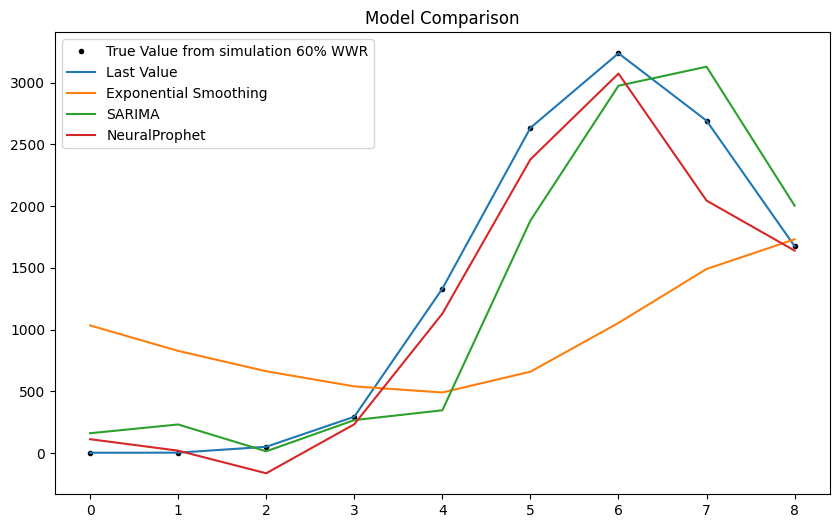

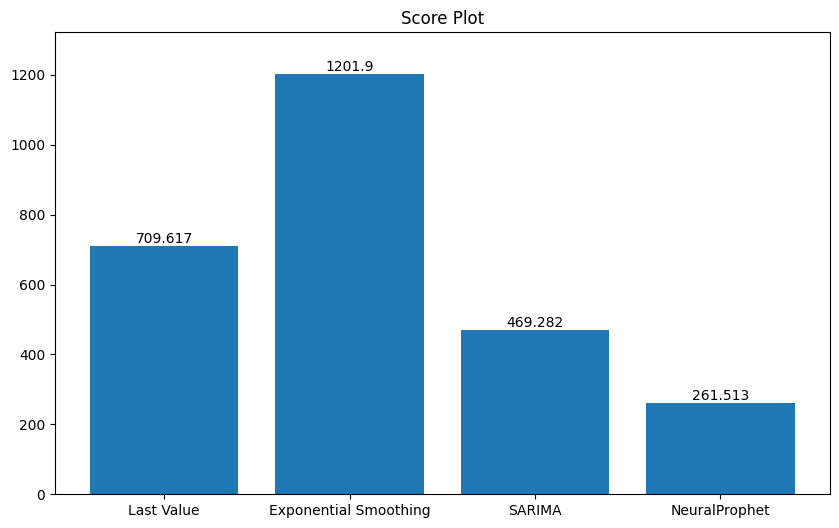

In [121]:
def comparison_plot():
    """Visualizing the training + validation sets"""
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111)
    ax.set_title("Model Comparison")
    ax.plot(df_test["y"].values,'.k', label='True Value from simulation 60% WWR')
    ax.plot(last_val_preds, label="Last Value")
    ax.plot(exp_smooth_preds, label="Exponential Smoothing")
    ax.plot(sarima_preds, label="SARIMA")
    ax.plot(neuralprophet_preds, label="NeuralProphet")
    ax.legend()
    plt.show()
    
def score_plot():
    """Visualizing the training + validation sets"""
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111)
    
    scores = {
        "Last Value": last_val_rmse,
        "Exponential Smoothing": exp_smooth_rmse,
        "SARIMA": sarima_rmse,
        "NeuralProphet": neuralprophet_rmse,
    }
    
    ax.set_title("Score Plot")
    ax.bar(scores.keys(), scores.values())
    ax.bar_label(ax.containers[0], label_type='edge')
    ax.margins(y=0.1)
    plt.show()
    
comparison_plot()
score_plot()

In [66]:
# The predictions from the NeuralProphet model could be used as an input feature to an LGBM/XGBoost model.
#This would likely yield a very forecast.